In [1]:
import numpy as np
import sys
import os

# Get the parent directory and add it to sys.path
parent_dir = os.path.abspath(os.path.join(os.getcwd(), os.pardir))
sys.path.append(parent_dir)

# Now import the class
# from multi_dim_env import MultivariatePolyEnv

In [4]:
def shift_polynomial(self):
        """
        Randomize the polynomial parameters to create a new function.
        'a' should remain negative to ensure a mountain shape.
        """
        self.a = np.random.uniform(-2.0, -0.5)  # Keep a negative for a mountain shape
        self.b = np.random.uniform(-5.0, 5.0)   # Random slope
        self.c = np.random.uniform(5.0, 20.0)   # Random height
        
        # Compute the new peak position
        self.x_max = -self.b / (2 * self.a)

        # Ensure the peak is within the valid range
        self.x_max = np.clip(self.x_max, self.x_range[0], self.x_range[1])
        
def compute_y(self, x):
        """
        Compute the polynomial value at x: f(x) = a*x^2 + b*x + c.
        """
        return self.a * x**2 + self.b * x + self.c

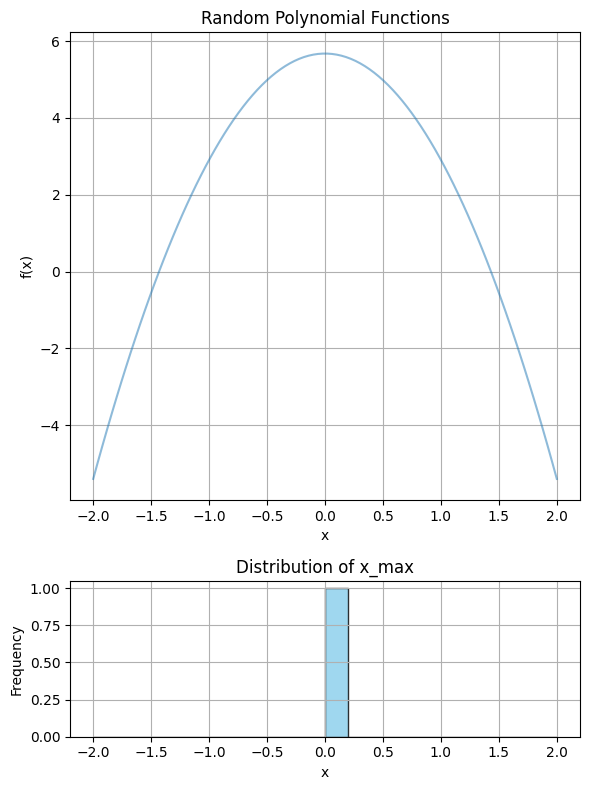

In [2]:
import matplotlib.pyplot as plt

# Assuming the class and methods are defined in the previous cells
class Polynomial:
    def __init__(self, x_range):
        self.x_range = x_range
        self.shift_polynomial()

    def shift_polynomial(self):
        """
        Randomize the polynomial parameters to create a new function.
        'a' should remain negative to ensure a mountain shape.
        """
        self.a = np.random.uniform(-2.0, -7.0)  # Keep a negative for a mountain shape
        self.b = np.random.uniform(0, 0)   # Random slope
        self.c = np.random.uniform(5.0, 20.0)   # Random height
        
        # Compute the new peak position
        self.x_max = -self.b / (2 * self.a)

        # Ensure the peak is within the valid range
        self.x_max = np.clip(self.x_max, self.x_range[0], self.x_range[1])
        

    def compute_y(self, x):
        """
        Compute the polynomial value at x: f(x) = a*x^2 + b*x + c.
        """
        return self.a * x**2 + self.b * x + self.c

# Generate x values
x_values = np.linspace(-2, 2, 100)

# Create a figure with two subplots (polynomials and histogram)
fig, ax = plt.subplots(2, 1, figsize=(6, 8), gridspec_kw={'height_ratios': [3, 1]})

# List to store x_max values
max_x_values = []

# Generate and plot 100 functions
for _ in range(1):
    poly = Polynomial(x_range=(-2, 2))
    y_values = poly.compute_y(x_values)
    max_x_values.append(poly.x_max)  # Store max_x values
    ax[0].plot(x_values, y_values, alpha=0.5)

# Configure main plot
ax[0].set_title('Random Polynomial Functions')
ax[0].set_xlabel('x')
ax[0].set_ylabel('f(x)')
ax[0].grid(True)

# Plot histogram of max_x values
ax[1].hist(max_x_values, bins=20, range=(-2, 2), color='skyblue', edgecolor='black', alpha=0.8)
ax[1].set_title('Distribution of x_max')
ax[1].set_xlabel('x')
ax[1].set_ylabel('Frequency')
ax[1].grid(True)

# Adjust layout and show plot
plt.tight_layout()
plt.show()

Randomized polynomial parameters:
  x_max = [-0.6518235  -2.64378788]
  c = 11.937652773967603
  weights = [0.6278425  0.55354681]
  f(x_max) = 11.937652773967603
  Max of Z = 11.936621678213035
  Max location in grid = (-0.612244897959183, -2.6530612244897958)


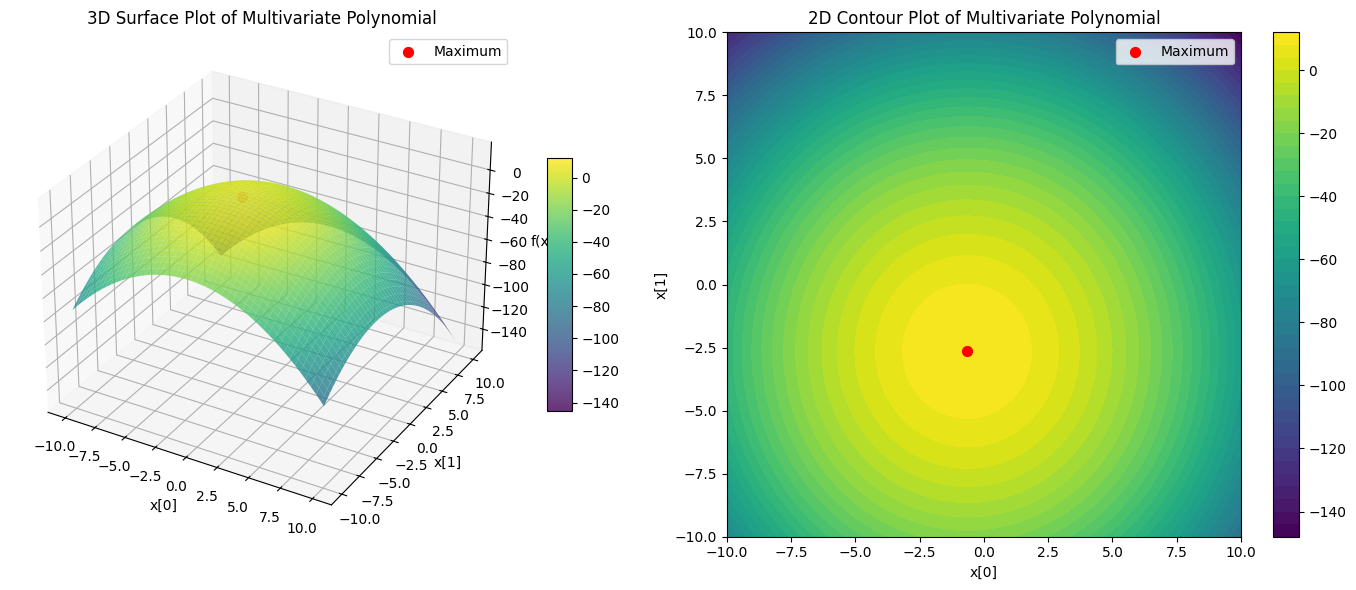

In [34]:
import matplotlib.pyplot as plt
import numpy as np
from mpl_toolkits.mplot3d import Axes3D  # required for 3D plotting

# Assuming the MultivariatePolyEnv code from before is available in the namespace.
# For demonstration, we instantiate the environment with action_dim=2.
class MultivariatePolyEnv:
    def __init__(self, env_config=None, degree=2, action_dim=2, x_range=(-10, 10), max_episode_steps=12):
        self.degree = degree
        self.action_dim = action_dim
        self.x_range = x_range  # same range for each dimension
        self.max_episode_steps = max_episode_steps
        # Initialize polynomial parameters (will be randomized on reset/shift)
        self.x_max = None
        self.c = None
        self.weights = None
        self.shift_polynomial()
    
    def shift_polynomial(self):
        # Randomize the maximum location uniformly for each dimension.
        self.x_max = np.random.uniform(self.x_range[0], self.x_range[1], size=(self.action_dim,))
        # Randomize the constant such that f(x_max) = c, and weights.
        self.c = np.random.uniform(5.0, 20.0)
        self.weights = np.random.uniform(0.5, 1.0, size=(self.action_dim,))
    
    # def compute_y(self, x):
    #     """
    #     Compute the polynomial value:
    #         f(x) = c - sum_{i=1}^{action_dim} (w_i * (x_i - x_max_i)**degree)
    #     """
    #     diff = x - self.x_max
    #     return self.c - np.sum(self.weights * (diff ** self.degree))
    
    def compute_y(self, x):
        """
        Compute the polynomial value for a batch of inputs:
            f(x) = c - sum_{i=1}^{action_dim} (w_i * (x_i - x_max_i)**degree)
            
        Supports inputs of shape `(batch_size, action_dim)`.
        If `x` is `(action_dim,)`, it is treated as `(1, action_dim)`.
        """
        x = np.atleast_2d(x)  # Ensure x is (batch_size, action_dim)
        
        # Compute difference
        diff = x - self.x_max  # Shape: (batch_size, action_dim)
        
        # Compute weighted polynomial term
        weighted_term = self.weights * (diff ** self.degree)  # Shape: (batch_size, action_dim)
        
        # Sum across action_dim to get final output
        result = self.c - np.sum(weighted_term, axis=1)  # Shape: (batch_size,)
        
        return result.squeeze()  # Convert (1,) to scalar if needed
    

# Create an instance of the environment.
env = MultivariatePolyEnv(degree=2, action_dim=2, x_range=(-10, 10))

env.shift_polynomial()
print("Randomized polynomial parameters:")
print("  x_max =", env.x_max)
print("  c =", env.c)
print("  weights =", env.weights)

f_at_xmax = env.compute_y(env.x_max)
print("  f(x_max) =", f_at_xmax)

# Build a grid, compute Z, and find the max:
x0 = np.linspace(env.x_range[0], env.x_range[1], 50)
x1 = np.linspace(env.x_range[0], env.x_range[1], 50)
X0, X1 = np.meshgrid(x0, x1)

Z = env.c - (env.weights[0] * ((X0 - env.x_max[0]) ** env.degree)
           + env.weights[1] * ((X1 - env.x_max[1]) ** env.degree))

Z_max = np.max(Z)
max_idx = np.unravel_index(np.argmax(Z), Z.shape)
max_loc = (X0[max_idx], X1[max_idx])

print("  Max of Z =", Z_max)
print("  Max location in grid =", max_loc)

# Create a grid over the 2D input space.
grid_points = 100
x0 = np.linspace(env.x_range[0], env.x_range[1], grid_points)
x1 = np.linspace(env.x_range[0], env.x_range[1], grid_points)
X0, X1 = np.meshgrid(x0, x1)

# print(f'X0 shape: {X0.shape}, X1 shape: {X1.shape}', X0)

# Compute function values on the grid.
# Since our function is separable, we can compute:
# f(x) = c - (w0*(x0 - x_max[0])**degree + w1*(x1 - x_max[1])**degree)
Z = env.c - (env.weights[0] * ((X0 - env.x_max[0]) ** env.degree) +
             env.weights[1] * ((X1 - env.x_max[1]) ** env.degree))

# Prepare the figure.
fig = plt.figure(figsize=(14, 6))

# --- 3D Surface Plot ---
ax1 = fig.add_subplot(1, 2, 1, projection='3d')
surf = ax1.plot_surface(X0, X1, Z, cmap='viridis', edgecolor='none', alpha=0.8)
ax1.set_title('3D Surface Plot of Multivariate Polynomial')
ax1.set_xlabel('x[0]')
ax1.set_ylabel('x[1]')
ax1.set_zlabel('f(x)')
# Mark the maximum location: f(x_max)=c.
ax1.scatter(env.x_max[0], env.x_max[1], env.c, color='r', s=50, label='Maximum')
ax1.legend()
fig.colorbar(surf, ax=ax1, shrink=0.5, aspect=10)

# --- 2D Contour Plot ---
ax2 = fig.add_subplot(1, 2, 2)
cont = ax2.contourf(X0, X1, Z, levels=50, cmap='viridis')
ax2.set_title('2D Contour Plot of Multivariate Polynomial')
ax2.set_xlabel('x[0]')
ax2.set_ylabel('x[1]')
# Mark the maximum location on the contour plot.
ax2.scatter(env.x_max[0], env.x_max[1], color='r', s=50, label='Maximum')
ax2.legend()
fig.colorbar(cont, ax=ax2)

plt.tight_layout()
plt.show()


In [7]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D


def visualize_multivariate_polynomial(env, num_functions=100):
    """
    Visualize multiple random functions from the multivariate polynomial environment.
    
    Args:
        env: MultivariatePolynomialEnv instance
        num_functions: Number of random functions to generate
    """
    if env.num_dimensions == 2:
        visualize_2d(env, num_functions)
    else:
        visualize_nd(env, num_functions)

def visualize_2d(env, num_functions):
    """Visualize 2D polynomial functions using contour plots."""
    # Create grid of points
    x = np.linspace(env.x_range[0], env.x_range[1], 100)
    y = np.linspace(env.x_range[0], env.x_range[1], 100)
    X, Y = np.meshgrid(x, y)
    
    # Create figure with subplots
    fig = plt.figure(figsize=(15, 5))
    
    # Plot one random function as contour
    ax1 = fig.add_subplot(131)
    env.shift_polynomial()
    Z = np.zeros_like(X)
    for i in range(X.shape[0]):
        for j in range(X.shape[1]):
            point = np.array([X[i,j], Y[i,j]])
            Z[i,j] = env.compute_y(point)
    
    contour = ax1.contourf(X, Y, Z, levels=20, cmap='viridis')
    ax1.plot(env.x_max[0], env.x_max[1], 'r*', markersize=10, label='Maximum')
    ax1.set_title('Sample Function Contour')
    ax1.set_xlabel('x₁')
    ax1.set_ylabel('x₂')
    fig.colorbar(contour, ax=ax1)
    ax1.legend()
    
    # Plot one random function as 3D surface
    ax2 = fig.add_subplot(132, projection='3d')
    ax2.plot_surface(X, Y, Z, cmap='viridis', alpha=0.8)
    ax2.set_title('Sample Function Surface')
    ax2.set_xlabel('x₁')
    ax2.set_ylabel('x₂')
    ax2.set_zlabel('f(x₁,x₂)')
    
    # Plot distribution of maxima
    ax3 = fig.add_subplot(133)
    max_points = []
    for _ in range(num_functions):
        env.shift_polynomial()
        max_points.append(env.x_max)
    max_points = np.array(max_points)
    
    ax3.scatter(max_points[:,0], max_points[:,1], alpha=0.5)
    ax3.set_title('Distribution of Maxima')
    ax3.set_xlabel('x₁')
    ax3.set_ylabel('x₂')
    ax3.grid(True)
    
    plt.tight_layout()
    plt.show()

def visualize_nd(env, num_functions):
    """Visualize higher-dimensional polynomial functions using 1D slices."""
    # Create figure with subplots
    fig, axes = plt.subplots(1, env.num_dimensions, figsize=(5*env.num_dimensions, 4))
    if env.num_dimensions == 1:
        axes = [axes]
    
    # Generate base point at maximum
    env.shift_polynomial()
    base_point = env.x_max.copy()
    x = np.linspace(env.x_range[0], env.x_range[1], 100)
    
    # Plot 1D slices through maximum for each dimension
    for dim in range(env.num_dimensions):
        ax = axes[dim]
        
        # Create and plot multiple functions
        for _ in range(num_functions):
            env.shift_polynomial()
            base_point = env.x_max.copy()
            y_values = []
            
            for x_val in x:
                point = base_point.copy()
                point[dim] = x_val
                y_values.append(env.compute_y(point))
            
            ax.plot(x, y_values, alpha=0.3)
            ax.plot(env.x_max[dim], env.compute_y(env.x_max), 'r*', markersize=5)
        
        ax.set_title(f'Dimension {dim+1} Slice')
        ax.set_xlabel(f'x_{dim+1}')
        ax.set_ylabel('f(x)')
        ax.grid(True)
    
    plt.tight_layout()
    plt.show()
    
# env = MultivariatePolynomialEnv(num_dimensions=2, x_range=(-2, 2))
# visualize_multivariate_polynomial(env, num_functions=1)


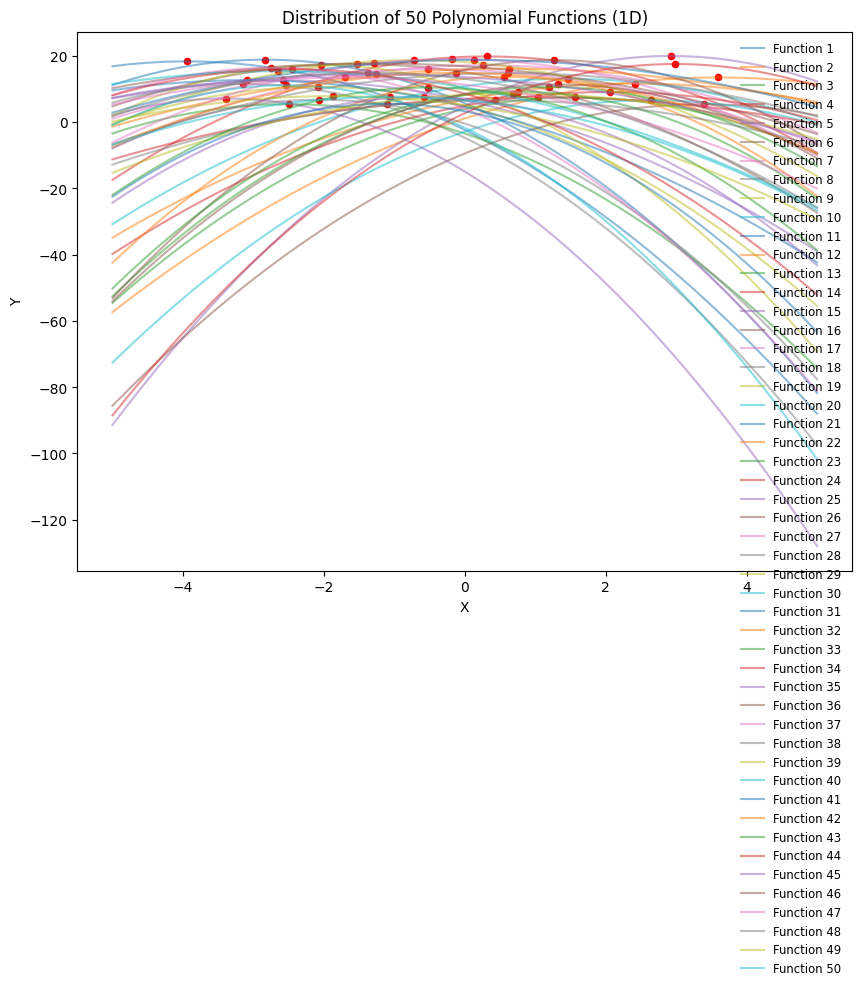

In [17]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

class PolynomialFunction:
    def __init__(self, action_dim, degree, x_range):
        self.action_dim = action_dim
        self.degree = degree
        self.x_range = x_range
        self.shift_polynomial()

    def shift_polynomial(self):
        # Randomize the maximum location uniformly for each dimension.
        # self.x_max = np.random.uniform(2.0, 2.0, size=(1, self.action_dim))
        # # Randomize the constant such that f(x_max) = c, and weights.
        # self.c = np.random.uniform(10.0, 10.0)
        # self.weights = np.random.uniform(0.5, 0.5, size=(self.action_dim,))
        self.x_max = np.random.uniform(self.x_range[0] * 0.8, self.x_range[1] * 0.8, size=(1, self.action_dim))
        self.c = np.random.uniform(5.0, 20.0)
        self.weights = np.random.uniform(0.5, 2.0, size=(self.action_dim,))

    def compute_y(self, x):
        """
        Compute the polynomial value for a batch of inputs:
            f(x) = c - sum_{i=1}^{action_dim} (w_i * (x_i - x_max_i)**degree)
        """
        x = np.atleast_2d(x)  # Ensure x is (batch_size, action_dim)
        diff = x - self.x_max  # Compute difference
        weighted_term = self.weights * (diff ** self.degree)  # Apply weights
        result = self.c - np.sum(weighted_term, axis=1)  # Sum across dimensions
        return result.squeeze()  # Convert (1,) to scalar if needed

    def plot_3d(self, num_points=50):
        """
        Generate a 3D scatter plot for action_dim=2.
        """
        if self.action_dim != 2:
            raise ValueError("3D plotting is only supported for action_dim=2")

        # Generate a grid of points
        x1_vals = np.linspace(self.x_range[0], self.x_range[1], num_points)
        x2_vals = np.linspace(self.x_range[0], self.x_range[1], num_points)
        X1, X2 = np.meshgrid(x1_vals, x2_vals)
        X_grid = np.column_stack([X1.ravel(), X2.ravel()])  # Flatten to (num_points**2, 2)

        # Compute function values
        Y = self.compute_y(X_grid)

        # Plot
        fig = plt.figure(figsize=(10, 7))
        ax = fig.add_subplot(111, projection='3d')

        # Scatter plot
        ax.scatter(X_grid[:, 0], X_grid[:, 1], Y, c=Y, cmap='viridis', alpha=0.75)
        print(np.max(Y))
        # Mark the maximum
        print(self.x_max, self.c)
        ax.scatter(self.x_max[0,0], self.x_max[0,1], self.c, color='red', s=100, label="Maximum (x_max)")

        # Labels
        ax.set_xlabel("X1")
        ax.set_ylabel("X2")
        ax.set_zlabel("Y")
        ax.set_title("3D Scatter Plot of Polynomial Function")

        plt.legend()
        plt.show()
        
    def plot_2d(self, num_points=100):
        """
        Generate a 2D plot for action_dim=1.
        """
        if self.action_dim != 1:
            raise ValueError("2D plotting is only supported for action_dim=1")
            
        # Generate a range of x values and compute corresponding y values.
        x_vals = np.linspace(self.x_range[0], self.x_range[1], num_points)
        y_vals = []
        for i in range(len(x_vals)):
            y = self.compute_y(x_vals[i])
            y_vals.append(y)
        # y_vals = self.compute_y(x_vals)
        y_vals = np.array(y_vals)
        
        print(y_vals.shape)
        
        # Create the plot.
        fig, ax = plt.subplots(figsize=(10, 7))
        ax.plot(x_vals, y_vals, label="Polynomial Function", color='blue')
        
        # Mark the maximum point.
        ax.scatter(self.x_max[0, 0], self.c, color='red', s=100, label="Maximum (x_max)")
        
        # Set labels and title.
        ax.set_xlabel("X")
        ax.set_ylabel("Y")
        ax.set_title("2D Plot of Polynomial Function")
        ax.legend()
        plt.show()

    def plot_3d(self, num_points=50):
        """
        Generate a 3D scatter plot for action_dim=2.
        """
        if self.action_dim != 2:
            raise ValueError("3D plotting is only supported for action_dim=2")

        # Generate a grid of points
        x1_vals = np.linspace(self.x_range[0], self.x_range[1], num_points)
        x2_vals = np.linspace(self.x_range[0], self.x_range[1], num_points)
        X1, X2 = np.meshgrid(x1_vals, x2_vals)
        X_grid = np.column_stack([X1.ravel(), X2.ravel()])  # Flatten to (num_points**2, 2)

        # Compute function values
        Y = self.compute_y(X_grid)

        # Plot
        fig = plt.figure(figsize=(10, 7))
        ax = fig.add_subplot(111, projection='3d')
        ax.scatter(X_grid[:, 0], X_grid[:, 1], Y, c=Y, cmap='viridis', alpha=0.75)

        # Mark the maximum
        ax.scatter(self.x_max[0,0], self.x_max[0,1], self.c, color='red', s=100, label="Maximum (x_max)")

        # Labels
        ax.set_xlabel("X1")
        ax.set_ylabel("X2")
        ax.set_zlabel("Y")
        ax.set_title("3D Scatter Plot of Polynomial Function")
        plt.legend()
        plt.show()

# Example Usage for 2D Plotting (action_dim=1)
# poly_fn = PolynomialFunction(action_dim=1, degree=2, x_range=(-5, 5))
# poly_fn.plot_2d()

# # Example Usage
# poly_fn = PolynomialFunction(action_dim=2, degree=2, x_range=(-5, 5))
# poly_fn.plot_3d()

def plot_2d_distribution(x_range=(-5, 5), degree=2, num_functions=10, num_points=100):
    """
    Plot a distribution of multiple 1D polynomial functions on the same graph.
    """
    x_vals = np.linspace(x_range[0], x_range[1], num_points)
    
    fig, ax = plt.subplots(figsize=(10, 7))

    for i in range(num_functions):
        # Create a new randomized polynomial function
        poly = PolynomialFunction(action_dim=1, degree=degree, x_range=x_range)
        y_vals = np.array([poly.compute_y([x]) for x in x_vals])
        
        # Plot the polynomial
        ax.plot(x_vals, y_vals, alpha=0.5, label=f'Function {i+1}')
        ax.scatter(poly.x_max[0, 0], poly.c, color='red', s=20)

    ax.set_xlabel("X")
    ax.set_ylabel("Y")
    ax.set_title(f"Distribution of {num_functions} Polynomial Functions (1D)")
    ax.legend(loc="upper right", fontsize="small", frameon=False)
    plt.show()

plot_2d_distribution(num_functions=50)


In [9]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

class FourierMultiPeakFunction:
    def __init__(self, action_dim, x_range, num_harmonics=3):
        self.action_dim = action_dim
        self.x_range = x_range
        self.num_harmonics = num_harmonics
        self.shift_fourier_multipeak()

    def shift_fourier_multipeak(self):
        self.c = np.random.uniform(5.0, 20.0)
        self.A = np.random.uniform(0.5, 3.0, size=(self.action_dim, self.num_harmonics))  # amplitudes
        self.B = np.random.uniform(0.5, 4.0, size=(self.action_dim, self.num_harmonics))  # frequencies
        self.shift = np.random.uniform(
            self.x_range[0], self.x_range[1], size=(self.action_dim, self.num_harmonics)
        )  # shifts
        self.phase = np.random.uniform(0, 2 * np.pi, size=(self.action_dim, self.num_harmonics))  # phases

    def compute_y(self, x):
        x = np.atleast_2d(x)  # Ensure batch shape
        result = np.full((x.shape[0],), self.c)
        for i in range(self.action_dim):
            for k in range(self.num_harmonics):
                diff = x[:, i] - self.shift[i, k]
                result += self.A[i, k] * np.cos(self.B[i, k] * diff + self.phase[i, k])
        return result.squeeze()

    def plot_2d(self, num_points=500):
        """
        Generate a 2D plot for action_dim=1
        """
        if self.action_dim != 1:
            raise ValueError("2D plotting only supported for action_dim=1")

        x_vals = np.linspace(self.x_range[0], self.x_range[1], num_points)
        y_vals = self.compute_y(x_vals[:, None])

        plt.figure(figsize=(10, 6))
        plt.plot(x_vals, y_vals, label="Fourier Multi-Peak Function", color="blue")
        plt.xlabel("X")
        plt.ylabel("Y")
        plt.title("2D Plot of Multi-Peak Fourier Function")
        plt.legend()
        plt.show()

    def plot_3d(self, num_points=80):
        """
        Generate a 3D scatter plot for action_dim=2
        """
        if self.action_dim != 2:
            raise ValueError("3D plotting is only supported for action_dim=2")

        x1_vals = np.linspace(self.x_range[0], self.x_range[1], num_points)
        x2_vals = np.linspace(self.x_range[0], self.x_range[1], num_points)
        X1, X2 = np.meshgrid(x1_vals, x2_vals)
        X_grid = np.column_stack([X1.ravel(), X2.ravel()])

        Y = self.compute_y(X_grid)

        fig = plt.figure(figsize=(10, 7))
        ax = fig.add_subplot(111, projection="3d")
        scatter = ax.scatter(X_grid[:, 0], X_grid[:, 1], Y, c=Y, cmap="viridis", alpha=0.7)

        ax.set_xlabel("X1")
        ax.set_ylabel("X2")
        ax.set_zlabel("Y")
        ax.set_title("3D Plot of Multi-Peak Fourier Function")
        fig.colorbar(scatter, ax=ax, shrink=0.5, aspect=5)
        plt.show()


    def find_bounds(self, resolution=1000):
        if self.action_dim == 1:
            x_vals = np.linspace(self.x_range[0], self.x_range[1], resolution)
            y_vals = self.compute_y(x_vals[:, None])
            self.f_max_empirical = np.max(y_vals)
            self.f_min_empirical = np.min(y_vals)
            self.f_max_theoretical = self.c + np.sum(np.abs(self.A))
            self.f_min_theoretical = self.c - np.sum(np.abs(self.A))
            return self.f_min_empirical, self.f_max_empirical, self.f_min_theoretical, self.f_max_theoretical

        elif self.action_dim == 2:
            x1_vals = np.linspace(self.x_range[0], self.x_range[1], int(np.sqrt(resolution)))
            x2_vals = np.linspace(self.x_range[0], self.x_range[1], int(np.sqrt(resolution)))
            X1, X2 = np.meshgrid(x1_vals, x2_vals)
            X_grid = np.column_stack([X1.ravel(), X2.ravel()])
            y_vals = self.compute_y(X_grid)
            self.f_max_empirical = np.max(y_vals)
            self.f_min_empirical = np.min(y_vals)
            self.f_max_theoretical = self.c + np.sum(np.abs(self.A))
            self.f_min_theoretical = self.c - np.sum(np.abs(self.A))
            return self.f_min_empirical, self.f_max_empirical, self.f_min_theoretical, self.f_max_theoretical

        else:
            # In higher dimensions, you can either do a random search or just return the theoretical bounds
            self.f_max_theoretical = self.c + np.sum(np.abs(self.A))
            self.f_min_theoretical = self.c - np.sum(np.abs(self.A))
            return None, None, self.f_min_theoretical, self.f_max_theoretical


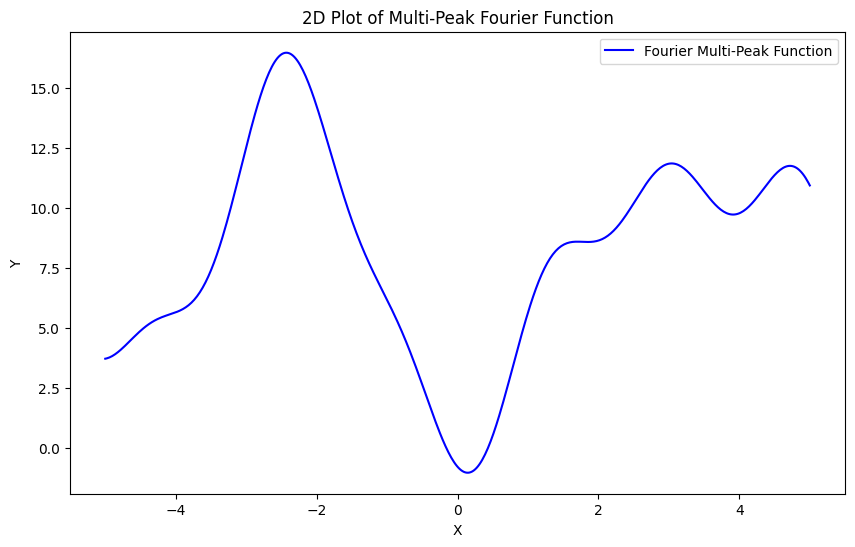

Empirical min: -1.0133697623341753, Empirical max: 16.462502027432212
Theoretical min bound: -2.6226299985561354, Theoretical max bound: 17.7260867968132


In [10]:
fourier_1d = FourierMultiPeakFunction(action_dim=1, x_range=(-5, 5), num_harmonics=5)
fourier_1d.plot_2d()
fmin_emp, fmax_emp, fmin_th, fmax_th = fourier_1d.find_bounds()
print(f"Empirical min: {fmin_emp}, Empirical max: {fmax_emp}")
print(f"Theoretical min bound: {fmin_th}, Theoretical max bound: {fmax_th}")


In [11]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

class ControlledFourierFunction:
    def __init__(self, action_dim, x_range):
        self.action_dim = action_dim
        self.x_range = x_range
        self._setup()

    def _setup(self):
        self.c = np.random.uniform(5.0, 20.0)
        self.A = np.random.uniform(1.0, 3.0, size=(self.action_dim,))
        self.B = np.random.uniform(0.5, 2.0, size=(self.action_dim,))
        self.shift = np.random.uniform(self.x_range[0], self.x_range[1], size=(self.action_dim,))

        # Precompute known extrema
        self.global_max_x = self.shift
        self.global_min_x = self.shift + (np.pi / self.B)
        self.global_max_y = self.c + np.sum(self.A)
        self.global_min_y = self.c - np.sum(self.A)

    def compute_y(self, x):
        x = np.atleast_2d(x)
        result = np.full(x.shape[0], self.c)
        for i in range(self.action_dim):
            result += self.A[i] * np.cos(self.B[i] * (x[:, i] - self.shift[i]))
        return result.squeeze()

    def plot_2d(self, num_points=500):
        if self.action_dim != 1:
            raise ValueError("2D plot only supported for action_dim=1.")
        x_vals = np.linspace(self.x_range[0], self.x_range[1], num_points)
        y_vals = self.compute_y(x_vals[:, None])

        plt.figure(figsize=(10, 6))
        plt.plot(x_vals, y_vals, label="Fourier function with known extrema")
        plt.scatter(self.global_max_x[0], self.global_max_y, color='red', s=100, label="Global Max")
        plt.scatter(self.global_min_x[0], self.global_min_y, color='blue', s=100, label="Global Min")
        plt.xlabel("x")
        plt.ylabel("f(x)")
        plt.title("Fourier Function with Known Max/Min")
        plt.legend()
        plt.show()

    def plot_3d(self, num_points=100):
        if self.action_dim != 2:
            raise ValueError("3D plot only supported for action_dim=2.")

        x1_vals = np.linspace(self.x_range[0], self.x_range[1], num_points)
        x2_vals = np.linspace(self.x_range[0], self.x_range[1], num_points)
        X1, X2 = np.meshgrid(x1_vals, x2_vals)
        grid_points = np.column_stack([X1.ravel(), X2.ravel()])

        y_vals = self.compute_y(grid_points)
        Y = y_vals.reshape(X1.shape)

        fig = plt.figure(figsize=(12, 8))
        ax = fig.add_subplot(111, projection="3d")
        surface = ax.plot_surface(X1, X2, Y, cmap="viridis", alpha=0.8, edgecolor='none')

        # Mark global max and min
        ax.scatter(self.global_max_x[0], self.global_max_x[1], self.global_max_y, color='red', s=120, label="Global Max")
        ax.scatter(self.global_min_x[0], self.global_min_x[1], self.global_min_y, color='blue', s=120, label="Global Min")

        ax.set_xlabel("X1")
        ax.set_ylabel("X2")
        ax.set_zlabel("f(x1, x2)")
        ax.set_title("3D Fourier Function with Known Max/Min")
        fig.colorbar(surface, ax=ax, shrink=0.5, aspect=5)
        ax.legend()
        plt.show()


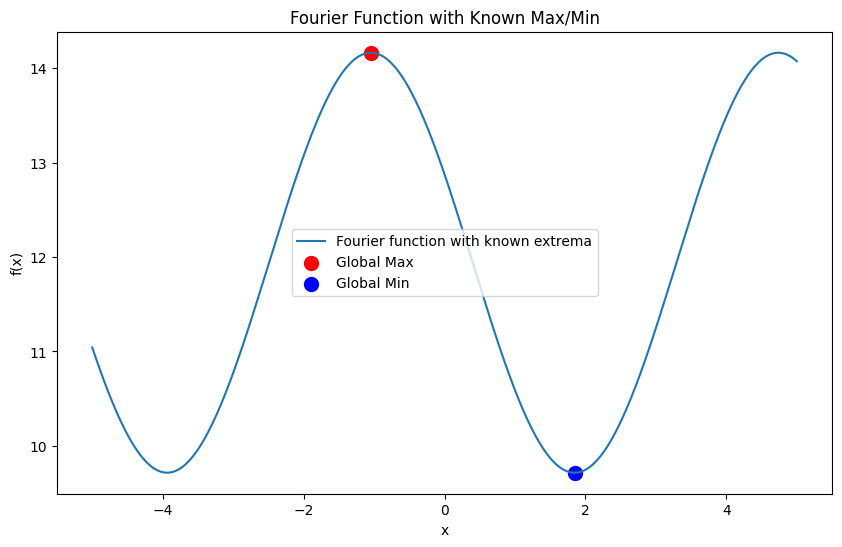

Global max at: [-1.04570622] with value: 14.162352478105067
Global min at: [1.84568222] with value: 9.715620512258536


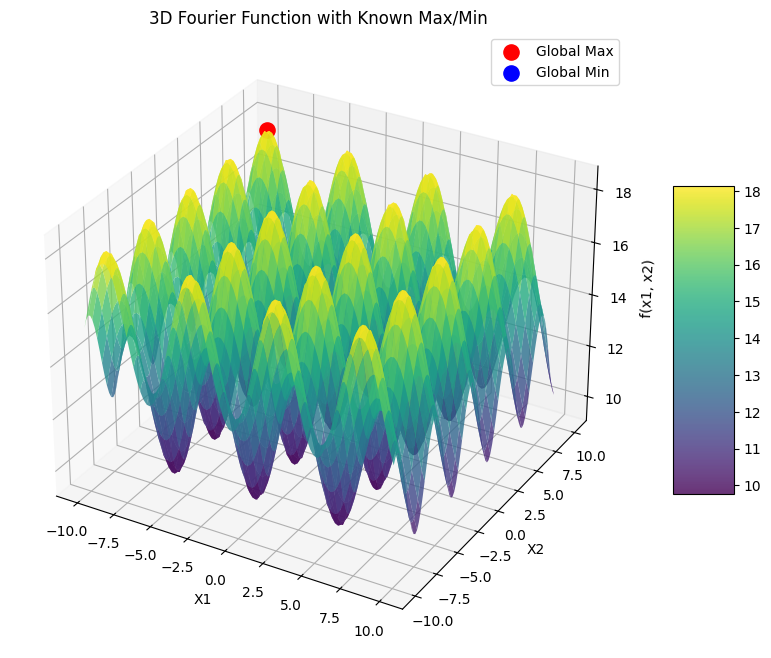

Global max at: [-8.56552738  7.95022453] with value: 18.245222836644214
Global min at: [-5.82417892 10.14099761] with value: 9.660633926684373


In [12]:
controlled_fourier = ControlledFourierFunction(action_dim=1, x_range=(-5, 5))
controlled_fourier.plot_2d()
print("Global max at:", controlled_fourier.global_max_x, "with value:", controlled_fourier.global_max_y)
print("Global min at:", controlled_fourier.global_min_x, "with value:", controlled_fourier.global_min_y)

cf_2d = ControlledFourierFunction(action_dim=2, x_range=(-10, 10))
cf_2d.plot_3d()
print("Global max at:", cf_2d.global_max_x, "with value:", cf_2d.global_max_y)
print("Global min at:", cf_2d.global_min_x, "with value:", cf_2d.global_min_y)



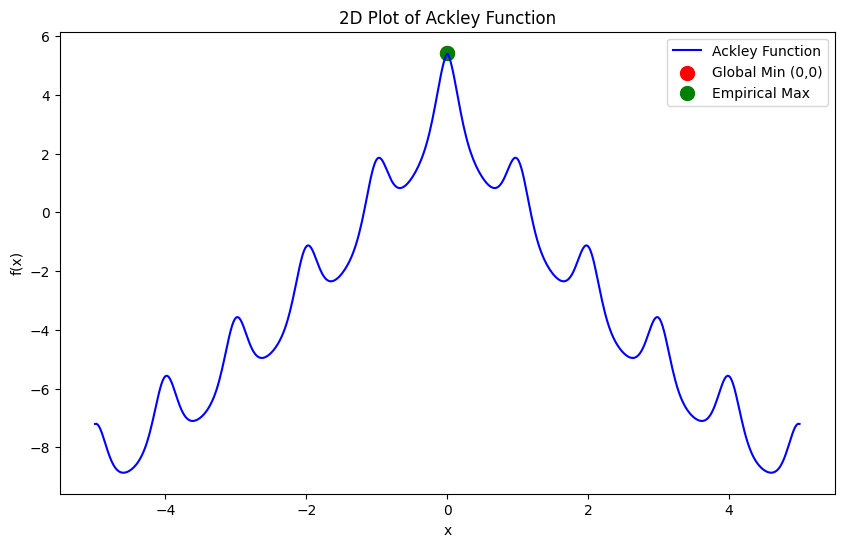

2D Ackley Global Min (known): (0, 5.4366)
2D Ackley Empirical Max: (-0.005005005005005003, 5.415209991369881)


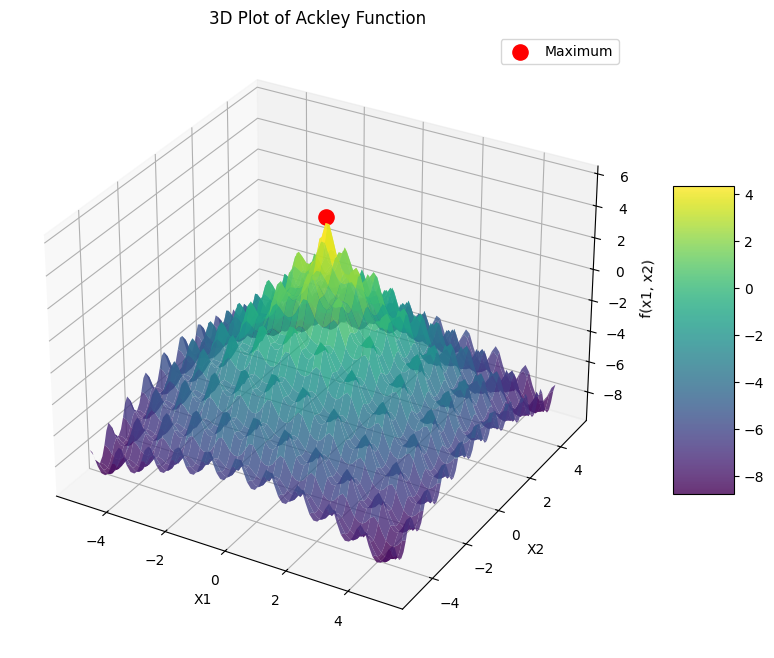

3D Ackley Global Min (known): ( [0. 0.] , 5.4366)
3D Ackley Empirical Max: (array([0., 0.]), 5.436563656918089)


In [44]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

class AckleyFunction:
    def __init__(self, action_dim, x_range, a=20, b=0.2, c=2*np.pi):
        """
        Ackley function typically defined as:
            f(x) = -a * exp(-b * sqrt((1/n)*sum(x^2))) - exp((1/n)*sum(cos(c*x))) + a + exp(1)
        where the global minimum is at x = 0 with f(0) = 0.
        
        Parameters:
            action_dim: number of dimensions.
            x_range: tuple (lower_bound, upper_bound) for each dimension.
            a, b, c: function parameters (defaults are standard).
        """
        self.action_dim = action_dim
        self.x_range = x_range
        self.a = a
        self.b = b
        self.c = c
        
        # Global minimum is known: x = 0, f(0)=0.
        self.global_min_x = np.zeros(self.action_dim)
        self.global_min_y = self.compute_y(self.global_min_x)
    
    def compute_y(self, x):
        """
        Compute the Ackley function.
        x should be an array of shape (n_points, action_dim) or (action_dim,)
        """
        x = np.atleast_2d(x)
        n = self.action_dim
        sum_sq = np.sum(x**2, axis=1)
        term1 = -self.a * np.exp(-self.b * np.sqrt(sum_sq / n))
        term2 = -np.exp(np.sum(np.cos(self.c * x), axis=1) / n)
        y = term1 + term2 + self.a + np.exp(1) * -1
        y = np.multiply(y, -1)
        return y.squeeze()
    
    def find_empirical_bounds(self, resolution=1000):
        """
        Evaluate the function on a dense grid (for 1D or 2D) to get empirical min/max.
        Returns:
            For 1D: ((x_min, f_min), (x_max, f_max))
            For 2D: ((x_min_vector, f_min), (x_max_vector, f_max))
        """
        if self.action_dim == 1:
            x_vals = np.linspace(self.x_range[0], self.x_range[1], resolution)
            y_vals = self.compute_y(x_vals[:, None])
            f_min = np.min(y_vals)
            f_max = np.max(y_vals)
            idx_min = np.argmin(y_vals)
            idx_max = np.argmax(y_vals)
            x_min = x_vals[idx_min]
            x_max = x_vals[idx_max]
            return (x_min, f_min), (x_max, f_max)
        elif self.action_dim == 2:
            num = int(np.sqrt(resolution))
            x1_vals = np.linspace(self.x_range[0], self.x_range[1], num)
            x2_vals = np.linspace(self.x_range[0], self.x_range[1], num)
            X1, X2 = np.meshgrid(x1_vals, x2_vals)
            grid_points = np.column_stack([X1.ravel(), X2.ravel()])
            y_vals = self.compute_y(grid_points)
            f_min = np.min(y_vals)
            f_max = np.max(y_vals)
            idx_min = np.argmin(y_vals)
            idx_max = np.argmax(y_vals)
            x_min = grid_points[idx_min]
            x_max = grid_points[idx_max]
            return (x_min, f_min), (x_max, f_max)
        else:
            return None, None
    
    def plot_2d(self, num_points=500):
        """
        Generate a 2D plot for action_dim = 1.
        Marks the known global minimum and the empirical maximum (via grid search).
        """
        if self.action_dim != 1:
            raise ValueError("2D plotting is only supported for action_dim=1")
            
        x_vals = np.linspace(self.x_range[0], self.x_range[1], num_points)
        y_vals = self.compute_y(x_vals[:, None])
        
        plt.figure(figsize=(10, 6))
        plt.plot(x_vals, y_vals, label="Ackley Function", color='blue')
        
        # Mark global minimum (known)
        plt.scatter(0, self.global_min_y, color='red', s=100, label="Global Min (0,0)")
        
        # Find empirical maximum from grid search and mark it.
        (_, _), (x_max_emp, f_max_emp) = self.find_empirical_bounds(resolution=num_points**2)
        plt.scatter(x_max_emp, f_max_emp, color='green', s=100, label="Empirical Max")
        
        plt.xlabel("x")
        plt.ylabel("f(x)")
        plt.title("2D Plot of Ackley Function")
        plt.legend()
        plt.show()
    
    def plot_3d(self, num_points=80):
        """
        Generate a 3D surface plot for action_dim = 2.
        Marks the known global minimum and the empirical maximum (via grid search).
        """
        if self.action_dim != 2:
            raise ValueError("3D plotting is only supported for action_dim=2")
            
        x1_vals = np.linspace(self.x_range[0], self.x_range[1], num_points)
        x2_vals = np.linspace(self.x_range[0], self.x_range[1], num_points)
        X1, X2 = np.meshgrid(x1_vals, x2_vals)
        grid_points = np.column_stack([X1.ravel(), X2.ravel()])
        Y = self.compute_y(grid_points).reshape(X1.shape)
        
        fig = plt.figure(figsize=(12, 8))
        ax = fig.add_subplot(111, projection='3d')
        surface = ax.plot_surface(X1, X2, Y, cmap="viridis", alpha=0.8, edgecolor='none')
        
        # Mark global minimum (known)
        ax.scatter(0, 0, self.global_min_y, color='red', s=120, label="Maximum")
        
        # Find empirical maximum from grid search and mark it.
        (_, _), (x_max_emp, f_max_emp) = self.find_empirical_bounds(resolution=num_points**2)
        # ax.scatter(x_max_emp[0], x_max_emp[1], f_max_emp, color='green', s=120, label="Empirical Max")
        
        ax.set_xlabel("X1")
        ax.set_ylabel("X2")
        ax.set_zlabel("f(x1, x2)")
        ax.set_title("3D Plot of Ackley Function")
        fig.colorbar(surface, shrink=0.5, aspect=5)
        ax.legend()
        plt.show()


# === Example Usage ===

# For 2D (action_dim=1) plot:
ackley_1d = AckleyFunction(action_dim=1, x_range=(-5, 5))
ackley_1d.plot_2d()
(empirical_min_1d, empirical_max_1d) = ackley_1d.find_empirical_bounds()
print("2D Ackley Global Min (known): (0, {:.4f})".format(ackley_1d.global_min_y))
print("2D Ackley Empirical Max:", empirical_max_1d)

# For 3D (action_dim=2) plot:
ackley_2d = AckleyFunction(action_dim=2, x_range=(-5, 5))
ackley_2d.plot_3d()
(empirical_min_2d, empirical_max_2d) = ackley_2d.find_empirical_bounds()
print("3D Ackley Global Min (known): (", np.zeros(2), ", {:.4f})".format(ackley_2d.global_min_y))
print("3D Ackley Empirical Max:", empirical_max_2d)


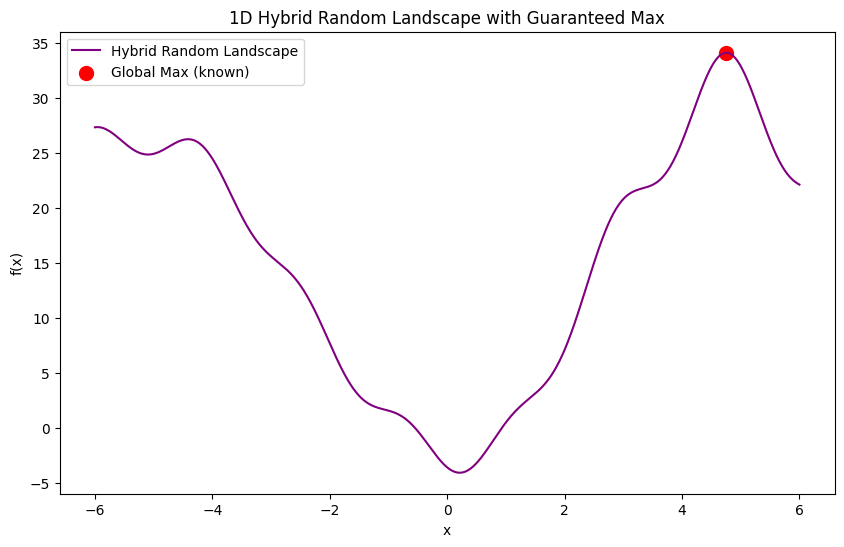

Global max at: [4.75388614] with theoretical max value: 34.07834838264603


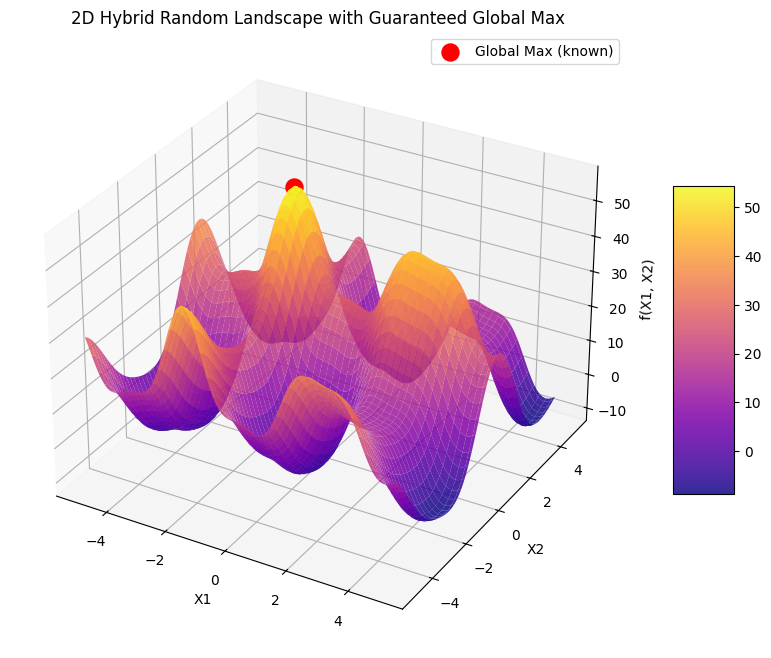

Global max at: [-1.73251122  1.14056665] with theoretical max value: 54.966475502284894


In [14]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

class HybridRandomLandscape:
    def __init__(self, action_dim, x_range, num_oscillations=10):
        """
        Parameters:
            action_dim: 1 or 2 dimensions supported for visualization
            x_range: tuple (low, high)
            num_oscillations: number of small random harmonics added for chaos
        """
        self.action_dim = action_dim
        self.x_range = x_range
        self.num_oscillations = num_oscillations
        self._setup()

    def _setup(self):
        self.c = np.random.uniform(5.0, 20.0)
        self.A0 = np.random.uniform(10.0, 20.0)  # large dominant amplitude
        self.B0 = np.random.uniform(0.5, 1.5, size=(self.action_dim,))
        self.s0 = np.random.uniform(self.x_range[0], self.x_range[1], size=(self.action_dim,))

        # All small oscillations also peak at s0 (shift = s0, phase=0)
        self.small_A = np.random.uniform(0.2, 3.0, size=(self.action_dim, self.num_oscillations))
        self.small_B = np.random.uniform(0.5, 4.0, size=(self.action_dim, self.num_oscillations))
        self.small_shift = np.tile(self.s0.reshape(-1, 1), (1, self.num_oscillations))  # force peak at s0
        self.small_phase = np.zeros((self.action_dim, self.num_oscillations))  # no random phase shift

        self.global_max_x = self.s0
        self.global_max_y = self.c + self.A0 * self.action_dim + np.sum(self.small_A)



    def compute_y(self, x):
        x = np.atleast_2d(x)
        result = np.full(x.shape[0], self.c)

        # Add big peak
        for i in range(self.action_dim):
            result += self.A0 * np.cos(self.B0[i] * (x[:, i] - self.s0[i]))

        # Add small random oscillations
        for i in range(self.action_dim):
            for k in range(self.num_oscillations):
                diff = x[:, i] - self.small_shift[i, k]
                result += self.small_A[i, k] * np.cos(self.small_B[i, k] * diff + self.small_phase[i, k])

        return result.squeeze()

    def plot_2d(self, num_points=800):
        if self.action_dim != 1:
            raise ValueError("2D plotting only for action_dim=1")

        x_vals = np.linspace(self.x_range[0], self.x_range[1], num_points)
        y_vals = self.compute_y(x_vals[:, None])

        plt.figure(figsize=(10, 6))
        plt.plot(x_vals, y_vals, label="Hybrid Random Landscape", color="purple")

        # Mark global max location
        plt.scatter(self.global_max_x[0], self.global_max_y, color="red", s=100, label="Global Max (known)")
        plt.xlabel("x")
        plt.ylabel("f(x)")
        plt.title("1D Hybrid Random Landscape with Guaranteed Max")
        plt.legend()
        plt.show()

    def plot_3d(self, num_points=100):
        if self.action_dim != 2:
            raise ValueError("3D plotting only for action_dim=2")

        x1_vals = np.linspace(self.x_range[0], self.x_range[1], num_points)
        x2_vals = np.linspace(self.x_range[0], self.x_range[1], num_points)
        X1, X2 = np.meshgrid(x1_vals, x2_vals)
        X_grid = np.column_stack([X1.ravel(), X2.ravel()])

        Y = self.compute_y(X_grid).reshape(X1.shape)

        fig = plt.figure(figsize=(12, 8))
        ax = fig.add_subplot(111, projection="3d")
        surf = ax.plot_surface(X1, X2, Y, cmap="plasma", alpha=0.85, edgecolor="none")

        # Mark global max
        ax.scatter(self.global_max_x[0], self.global_max_x[1], self.global_max_y, color="red", s=150, label="Global Max (known)")

        ax.set_xlabel("X1")
        ax.set_ylabel("X2")
        ax.set_zlabel("f(X1, X2)")
        ax.set_title("2D Hybrid Random Landscape with Guaranteed Global Max")
        fig.colorbar(surf, shrink=0.5, aspect=5)
        ax.legend()
        plt.show()


landscape_1d = HybridRandomLandscape(action_dim=1, x_range=(-6, 6), num_oscillations=8)
landscape_1d.plot_2d()
print("Global max at:", landscape_1d.global_max_x, "with theoretical max value:", landscape_1d.global_max_y)


landscape_2d = HybridRandomLandscape(action_dim=2, x_range=(-5, 5), num_oscillations=5)
landscape_2d.plot_3d()
print("Global max at:", landscape_2d.global_max_x, "with theoretical max value:", landscape_2d.global_max_y)


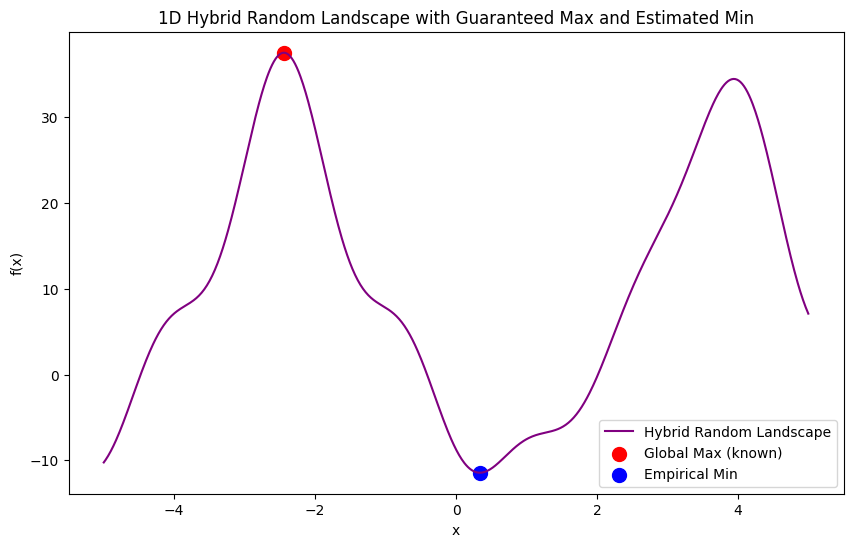

In [38]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

class HybridRandomLandscape:
    def __init__(self, action_dim, x_range, num_oscillations=10, grid_resolution=1000):
        """
        Parameters:
            action_dim: Number of dimensions
            x_range: Tuple (low, high) defining the space bounds
            num_oscillations: Number of small random oscillations per dimension
            grid_resolution: Number of points used for empirical min estimation
        """
        self.action_dim = action_dim
        self.x_range = x_range
        self.num_oscillations = num_oscillations
        self.grid_resolution = grid_resolution
        self._setup()

    def _setup(self):
        """Initializes the landscape with a known global max and random local structure."""
        # self.c = np.random.uniform(10.0, 10.0)  # Offset
        # self.A0 = np.random.uniform(15.0, 15.0)  # Large peak amplitude
        # self.B0 = np.random.uniform(1.1, 1.1, size=(self.action_dim,))  # Large peak frequency
        # self.s0 = np.random.uniform(0.5, 0.5, size=(self.action_dim,))  # Peak location

        # # Small oscillations (randomized)
        # self.small_A = np.random.uniform(2.0, 2.0, size=(self.action_dim, self.num_oscillations))
        # self.small_B = np.random.uniform(3.0, 3.0, size=(self.action_dim, self.num_oscillations))
        
        self.c = np.random.uniform(5.0, 20.0)  # Offset
        self.A0 = np.random.uniform(10.0, 20.0)  # Large peak amplitude
        self.B0 = np.random.uniform(0.5, 1.5, size=(self.action_dim,))  # Large peak frequency
        self.s0 = np.random.uniform(self.x_range[0], self.x_range[1], size=(self.action_dim,))  # Peak location

        # Small oscillations (randomized)
        self.small_A = np.random.uniform(0.2, 3.0, size=(self.action_dim, self.num_oscillations))
        self.small_B = np.random.uniform(0.5, 4.0, size=(self.action_dim, self.num_oscillations))
        
        # Force all oscillations to peak at s0 (ensuring known max)
        self.small_shift = np.tile(self.s0.reshape(-1, 1), (1, self.num_oscillations))  # Align peaks
        self.small_phase = np.zeros((self.action_dim, self.num_oscillations))  # No phase shifts

        # Compute known global max value (since all cosines are +1 at s0)
        self.global_max_x = self.s0
        self.global_max_y = self.c + self.A0 * self.action_dim + np.sum(self.small_A)

        # Compute theoretical min bound (all cosines at -1)
        self.min_bound = self.c - self.A0 * self.action_dim - np.sum(self.small_A)

        # Estimate empirical min by grid search
        self.estimate_empirical_min()

    def compute_y(self, x):
        """
        Computes the function value at given x points.
        x should be (n_points, action_dim) or (action_dim,)
        """
        x = np.atleast_2d(x)
        result = np.full(x.shape[0], self.c)

        # Add large peak
        for i in range(self.action_dim):
            result += self.A0 * np.cos(self.B0[i] * (x[:, i] - self.s0[i]))

        # Add small oscillations
        for i in range(self.action_dim):
            for k in range(self.num_oscillations):
                diff = x[:, i] - self.small_shift[i, k]
                result += self.small_A[i, k] * np.cos(self.small_B[i, k] * diff + self.small_phase[i, k])

        return result.squeeze()

    def estimate_empirical_min(self):
        """
        Finds the empirical minimum within the x_range by sampling a grid (for 1D or 2D).
        For higher dimensions, it uses random sampling.
        """
        if self.action_dim == 1:
            x_vals = np.linspace(self.x_range[0], self.x_range[1], self.grid_resolution)
            y_vals = self.compute_y(x_vals[:, None])
            self.empirical_min_x = x_vals[np.argmin(y_vals)]
            self.empirical_min_y = np.min(y_vals)

        elif self.action_dim == 2:
            num = int(np.sqrt(self.grid_resolution))
            x1_vals = np.linspace(self.x_range[0], self.x_range[1], num)
            x2_vals = np.linspace(self.x_range[0], self.x_range[1], num)
            X1, X2 = np.meshgrid(x1_vals, x2_vals)
            grid_points = np.column_stack([X1.ravel(), X2.ravel()])
            y_vals = self.compute_y(grid_points)
            min_idx = np.argmin(y_vals)
            self.empirical_min_x = grid_points[min_idx]
            self.empirical_min_y = y_vals[min_idx]

        else:
            # For high dimensions, use random search
            samples = np.random.uniform(self.x_range[0], self.x_range[1], size=(self.grid_resolution, self.action_dim))
            y_vals = self.compute_y(samples)
            min_idx = np.argmin(y_vals)
            self.empirical_min_x = samples[min_idx]
            self.empirical_min_y = y_vals[min_idx]

    def plot_2d(self, num_points=800):
        """Generates a 2D plot (only for action_dim=1)."""
        if self.action_dim != 1:
            raise ValueError("2D plotting only for action_dim=1")

        x_vals = np.linspace(self.x_range[0], self.x_range[1], num_points)
        y_vals = self.compute_y(x_vals[:, None])

        plt.figure(figsize=(10, 6))
        plt.plot(x_vals, y_vals, label="Hybrid Random Landscape", color="purple")

        # Mark global max location
        plt.scatter(self.global_max_x[0], self.global_max_y, color="red", s=100, label="Global Max (known)")
        # Mark empirical min location
        plt.scatter(self.empirical_min_x, self.empirical_min_y, color="blue", s=100, label="Empirical Min")

        plt.xlabel("x")
        plt.ylabel("f(x)")
        plt.title("1D Hybrid Random Landscape with Guaranteed Max and Estimated Min")
        plt.legend()
        plt.show()

    def plot_3d(self, num_points=100):
        """Generates a 3D plot (only for action_dim=2)."""
        if self.action_dim != 2:
            raise ValueError("3D plotting only for action_dim=2")

        x1_vals = np.linspace(self.x_range[0], self.x_range[1], num_points)
        x2_vals = np.linspace(self.x_range[0], self.x_range[1], num_points)
        X1, X2 = np.meshgrid(x1_vals, x2_vals)
        grid_points = np.column_stack([X1.ravel(), X2.ravel()])
        Y = self.compute_y(grid_points).reshape(X1.shape)

        fig = plt.figure(figsize=(12, 8))
        ax = fig.add_subplot(111, projection="3d")
        surf = ax.plot_surface(X1, X2, Y, cmap="plasma", alpha=0.85, edgecolor="none")

        # Mark global max
        ax.scatter(self.global_max_x[0], self.global_max_x[1], self.global_max_y, color="red", s=150, label="Global Max (known)")
        # Mark empirical min
        ax.scatter(self.empirical_min_x[0], self.empirical_min_x[1], self.empirical_min_y, color="blue", s=150, label="Empirical Min")

        ax.set_xlabel("X1")
        ax.set_ylabel("X2")
        ax.set_zlabel("f(X1, X2)")
        ax.set_title("2D Hybrid Random Landscape with Guaranteed Max and Estimated Min")
        fig.colorbar(surf, shrink=0.5, aspect=5)
        ax.legend()
        plt.show()
        
        
# landscape_1d = HybridRandomLandscape(action_dim=1, x_range=(-1, 1), num_oscillations=1)
# landscape_1d.plot_2d()
# print("Theoretical min bound:", landscape_1d.min_bound)
# print("Empirical min found at:", landscape_1d.empirical_min_x, "with value:", landscape_1d.empirical_min_y)

# landscape_2d = HybridRandomLandscape(action_dim=2, x_range=(-5, 5), num_oscillations=5)
# landscape_2d.plot_3d()
# print("Theoretical min bound:", landscape_2d.min_bound)
# print("Empirical min found at:", landscape_2d.empirical_min_x, "with value:", landscape_2d.empirical_min_y)
# print("Global max at:", landscape_2d.global_max_x, "with value:", landscape_2d.global_max_y)


landscape_2d = HybridRandomLandscape(action_dim=1, x_range=(-5, 5), num_oscillations=5)
landscape_2d.plot_2d()



In [16]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

class HybridRandomLandscape:
    def __init__(self, action_dim, x_range, num_oscillations=10, soft_factor=0.9):
        """
        Parameters:
            action_dim: number of dimensions
            x_range: (low, high) tuple
            num_oscillations: number of smaller oscillations per dimension
            soft_factor: scaling factor for realistic bounds (e.g., 0.9 for a conservative bound)
        """
        self.action_dim = action_dim
        self.x_range = x_range
        self.num_oscillations = num_oscillations
        self.soft_factor = soft_factor
        self._setup()

    def _setup(self):
        # Dominant large peak setup
        self.c = np.random.uniform(14.0, 14.0)
        self.A0 = np.random.uniform(15.0, 15.0)
        self.B0 = np.random.uniform(1.5, 1.5, size=(self.action_dim,))
        self.s0 = np.random.uniform(0.0, 0.0, size=(self.action_dim,))

        # Small chaotic oscillations
        self.small_A = np.random.uniform(1.2, 1.2, size=(self.action_dim, self.num_oscillations))
        self.small_B = np.random.uniform(2.5, 2.5, size=(self.action_dim, self.num_oscillations))
        
        # self.small_A = np.random.uniform(0.2, 3.0, size=(self.action_dim, self.num_oscillations))
        # self.small_B = np.random.uniform(0.5, 4.0, size=(self.action_dim, self.num_oscillations))
        
        self.small_shift = np.random.uniform(0.0, 0.0, size=(self.action_dim, self.num_oscillations))
        self.small_phase = np.random.uniform(np.pi,  np.pi, size=(self.action_dim, self.num_oscillations))

        # Theoretical hard bounds (perfect alignment max/min)
        self.hard_max_bound = self.c + self.action_dim * self.A0 + np.sum(self.small_A)
        self.hard_min_bound = self.c - self.action_dim * self.A0 - np.sum(self.small_A)
        
        self.max_x = self.s0
        self.max_y = self.c + self.A0 * self.action_dim + np.sum(self.small_A)
        
        print("max", self.max_x, self.max_y)

        # Soft (probabilistic) bounds — scaled smaller oscillations for realism
        self.soft_max_bound = self.c + self.action_dim * self.A0 + self.soft_factor * np.sum(self.small_A)
        self.soft_min_bound = self.c - self.action_dim * self.A0 - self.soft_factor * np.sum(self.small_A)

    def compute_y(self, x):
        x = np.atleast_2d(x)
        result = np.full(x.shape[0], self.c)

       
        # Add large peak
        for i in range(self.action_dim):
            result += self.A0 * np.cos(self.B0[i] * (x[:, i] - self.s0[i]))

        # Add small oscillations
        for i in range(self.action_dim):
            for k in range(self.num_oscillations):
                diff = x[:, i] - self.small_shift[i, k]
                result += self.small_A[i, k] * np.cos(self.small_B[i, k] * diff + self.small_phase[i, k])

        return result.squeeze()

    def get_bounds(self):
        print(f"Theoretical HARD bounds:")
        print(f"  Max ≤ {self.hard_max_bound:.3f}")
        print(f"  Min ≥ {self.hard_min_bound:.3f}")
        print(f"Soft (probabilistic) bounds (with factor {self.soft_factor}):")
        print(f"  Max ≤ {self.soft_max_bound:.3f}")
        print(f"  Min ≥ {self.soft_min_bound:.3f}")

    def plot_2d(self, num_points=800):
        if self.action_dim != 1:
            raise ValueError("2D plotting only for action_dim=1.")

        x_vals = np.linspace(self.x_range[0], self.x_range[1], num_points)
        y_vals = self.compute_y(x_vals[:, None])

        plt.figure(figsize=(10, 6))
        plt.plot(x_vals, y_vals, label="Hybrid Random Landscape", color="purple")

        # Mark theoretical hard bounds as horizontal lines
        plt.axhline(self.hard_max_bound, color='green', linestyle='--', label="Hard Max Bound")
        plt.axhline(self.hard_min_bound, color='orange', linestyle='--', label="Hard Min Bound")

        plt.xlabel("x")
        plt.ylabel("f(x)")
        plt.title("1D Hybrid Random Landscape with Theoretical Bounds")
        plt.legend()
        plt.show()

    def plot_3d(self, num_points=100):
        if self.action_dim != 2:
            raise ValueError("3D plotting only for action_dim=2.")

        x1_vals = np.linspace(self.x_range[0], self.x_range[1], num_points)
        x2_vals = np.linspace(self.x_range[0], self.x_range[1], num_points)
        X1, X2 = np.meshgrid(x1_vals, x2_vals)
        X_grid = np.column_stack([X1.ravel(), X2.ravel()])

        Y = self.compute_y(X_grid).reshape(X1.shape)

        fig = plt.figure(figsize=(12, 8))
        ax = fig.add_subplot(111, projection="3d")
        surf = ax.plot_surface(X1, X2, Y, cmap="plasma", alpha=0.85, edgecolor="none")

        ax.set_xlabel("X1")
        ax.set_ylabel("X2")
        ax.set_zlabel("f(X1, X2)")
        ax.set_title("2D Hybrid Random Landscape with Theoretical Bounds")
        fig.colorbar(surf, shrink=0.5, aspect=5)
        plt.show()


max [0.] 41.0
Theoretical HARD bounds:
  Max ≤ 41.000
  Min ≥ -13.000
Soft (probabilistic) bounds (with factor 0.9):
  Max ≤ 39.800
  Min ≥ -11.800


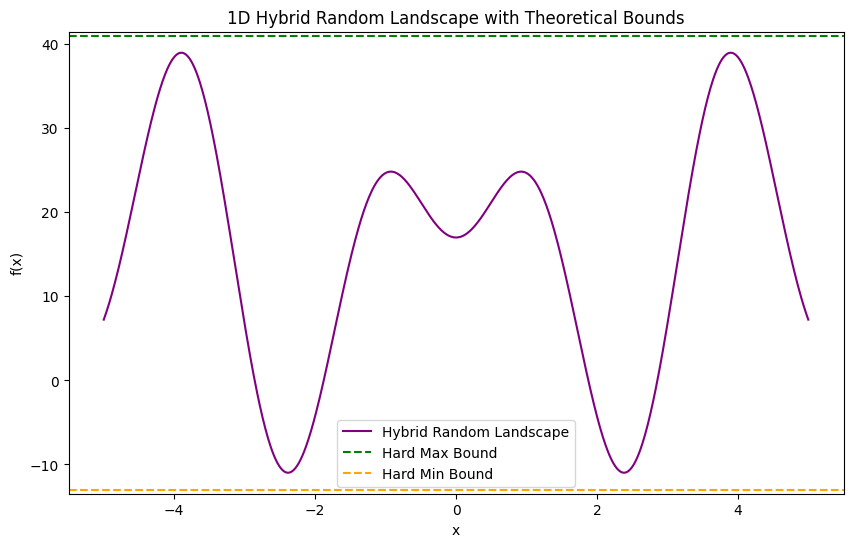

max [0. 0.] 80.0
Theoretical HARD bounds:
  Max ≤ 80.000
  Min ≥ -52.000
Soft (probabilistic) bounds (with factor 0.9):
  Max ≤ 76.400
  Min ≥ -48.400


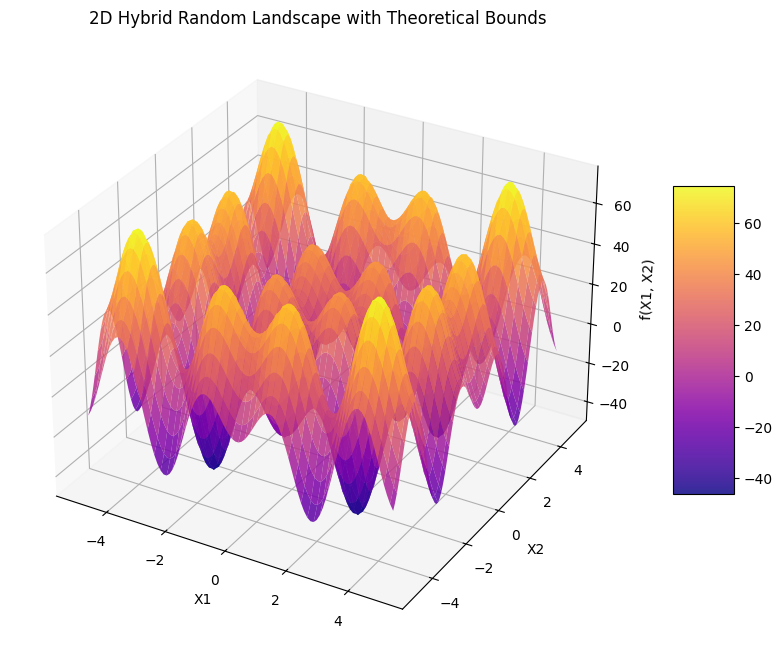

In [17]:
landscape_1d = HybridRandomLandscape(action_dim=1, x_range=(-5, 5), num_oscillations=10)
landscape_1d.get_bounds()
landscape_1d.plot_2d()


landscape_2d = HybridRandomLandscape(action_dim=2, x_range=(-5, 5), num_oscillations=15)
landscape_2d.get_bounds()
landscape_2d.plot_3d()



In [1]:
# %% [code]
# Import necessary libraries
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # required for 3D plotting

# Import the Ackley environment. Adjust the import path if needed.
# from ackley_env import AckleyEnv   # uncomment and update path if using an external file

# For demonstration purposes, here is the AckleyEnv definition.
# (You can comment out this block if you already have the class defined/imported.)
class AckleyEnv:
    def __init__(self, env_config=None):
        self.env_config = env_config
        self.x_range = env_config["bounds"]
        self.action_dim = env_config["action_dim"]
    def initialize_function(self):
        self.a = self.env_config.get("a", 20.0)
        self.b = self.env_config.get("b", 0.2)
        self.c = self.env_config.get("c", 2 * np.pi)
        lower, upper = self.x_range
        # choose optimum point in the central 60% of the domain
        self.optimum_point = np.random.uniform(lower + (upper - lower) * 0.2,
                                               upper - (upper - lower) * 0.2,
                                               size=(self.action_dim,))
        self.max_y = self.compute_y(self.optimum_point)
        if self.action_dim == 1 or self.action_dim == 2:
            (x_min, f_min), (_, _) = self.find_empirical_bounds(resolution=1000)
            self.min_y = f_min
        else:
            # For dimensions > 2: approximate min_y by evaluating the corners.
            corners = np.array(np.meshgrid(*[[lower, upper] for _ in range(self.action_dim)]))
            corners = corners.T.reshape(-1, self.action_dim)
            y_corners = self.compute_y(corners)
            self.min_y = np.min(y_corners)
    def compute_y(self, x):
        x = np.atleast_2d(x)
        n = self.action_dim
        # shift inputs so that the optimum is at 0.
        z = x - self.optimum_point
        sum_sq = np.sum(z ** 2, axis=1)
        term1 = -self.a * np.exp(-self.b * np.sqrt(sum_sq / n))
        term2 = -np.exp(np.sum(np.cos(self.c * z), axis=1) / n)
        f_val = term1 + term2 + self.a + np.exp(1)
        # flip the function so that the optimum is a maximum (value 0)
        y = -f_val
        return y.squeeze()
    def find_empirical_bounds(self, resolution=1000):
        if self.action_dim == 1:
            x_vals = np.linspace(self.x_range[0], self.x_range[1], resolution)
            y_vals = self.compute_y(x_vals[:, None])
            f_min = np.min(y_vals)
            f_max = np.max(y_vals)
            idx_min = np.argmin(y_vals)
            idx_max = np.argmax(y_vals)
            x_min = x_vals[idx_min]
            x_max = x_vals[idx_max]
            return (x_min, f_min), (x_max, f_max)
        elif self.action_dim == 2:
            num = int(np.sqrt(resolution))
            x1_vals = np.linspace(self.x_range[0], self.x_range[1], num)
            x2_vals = np.linspace(self.x_range[0], self.x_range[1], num)
            X1, X2 = np.meshgrid(x1_vals, x2_vals)
            grid_points = np.column_stack([X1.ravel(), X2.ravel()])
            y_vals = self.compute_y(grid_points)
            f_min = np.min(y_vals)
            f_max = np.max(y_vals)
            idx_min = np.argmin(y_vals)
            idx_max = np.argmax(y_vals)
            x_min = grid_points[idx_min]
            x_max = grid_points[idx_max]
            return (x_min, f_min), (x_max, f_max)
        else:
            return None, None

# Set the random seed for reproducibility
np.random.seed(42)


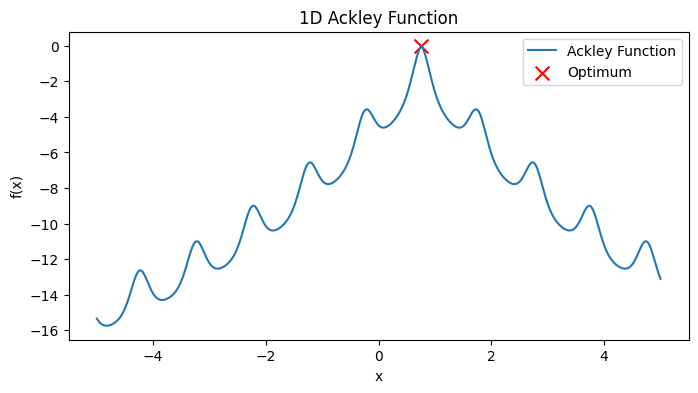

In [8]:
# %% [code]
import numpy as np
import matplotlib.pyplot as plt

# Minimal Ackley environment implementation for demonstration.
class AckleyEnv:
    def __init__(self, env_config):
        self.env_config = env_config
        self.x_range = env_config["bounds"]
        self.action_dim = env_config["action_dim"]
    
    def initialize_function(self):
        self.a = self.env_config.get("a", 20.0)
        self.b = self.env_config.get("b", 0.2)
        self.c = self.env_config.get("c", 2 * np.pi)
        lower, upper = self.x_range
        # Choose an optimum in the central 60% of the domain.
        self.optimum_point = np.random.uniform(lower + 0.2*(upper-lower),
                                               upper - 0.2*(upper-lower),
                                               size=(self.action_dim,))
        self.max_y = self.compute_y(self.optimum_point)
        # For 1D and 2D, use a dense grid for empirical bounds.
        (x_min, f_min), _ = self.find_empirical_bounds(resolution=1000)
        self.min_y = f_min

    def compute_y(self, x):
        x = np.atleast_2d(x)
        n = self.action_dim
        # Shift the input so the optimum is at zero.
        z = x - self.optimum_point
        sum_sq = np.sum(z**2, axis=1)
        term1 = -self.a * np.exp(-self.b * np.sqrt(sum_sq / n))
        term2 = -np.exp(np.sum(np.cos(self.c * z), axis=1)/n)
        f_val = term1 + term2 + self.a + np.exp(1)
        # Flip the function so that the optimum (at self.optimum_point) is a maximum.
        y = -f_val
        return y.squeeze()

    def find_empirical_bounds(self, resolution=1000):
        # Works for 1D.
        if self.action_dim == 1:
            x_vals = np.linspace(self.x_range[0], self.x_range[1], resolution)
            y_vals = self.compute_y(x_vals[:, None])
            f_min = np.min(y_vals)
            f_max = np.max(y_vals)
            idx_min = np.argmin(y_vals)
            idx_max = np.argmax(y_vals)
            x_min = x_vals[idx_min]
            x_max = x_vals[idx_max]
            return (x_min, f_min), (x_max, f_max)
        else:
            return None, None

# Configure the environment for a 1D Ackley function.
env_config_1d = {
    "bounds": (-5.0, 5.0),       # Domain for the input.
    "action_dim": 1,             # 1D input.
    "a": 20.0,
    "b": 0.2,
    "c": 2 * np.pi,
}

# Create and initialize the 1D Ackley environment.
env1d = AckleyEnv(env_config_1d)
env1d.initialize_function()

# Generate a grid of x values and compute the function.
x_vals = np.linspace(env_config_1d["bounds"][0], env_config_1d["bounds"][1], 500)
y_vals = env1d.compute_y(x_vals[:, None])  # reshape for 1D input

# Plot the 1D Ackley function.
plt.figure(figsize=(8, 4))
plt.plot(x_vals, y_vals, label="Ackley Function")
plt.scatter(env1d.optimum_point, env1d.max_y, color="red", marker="x", s=100, label="Optimum")
plt.title("1D Ackley Function")
plt.xlabel("x")
plt.ylabel("f(x)")
plt.legend()
plt.show()


In [9]:
# %% [code]
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # Enables 3D plotting

# Reuse the same AckleyEnv class defined earlier.

# Configure the environment for a 2D Ackley function.
env_config_2d = {
    "bounds": (-5.0, 5.0),
    "action_dim": 2,             # 2D input.
    "a": 20.0,
    "b": 0.2,
    "c": 2 * np.pi,
}

# Create and initialize the 2D Ackley environment.
env2d = AckleyEnv(env_config_2d)
env2d.initialize_function()

# Create a grid of (x, y) points.
num_points = 100
x1_vals = np.linspace(env_config_2d["bounds"][0], env_config_2d["bounds"][1], num_points)
x2_vals = np.linspace(env_config_2d["bounds"][0], env_config_2d["bounds"][1], num_points)
X, Y = np.meshgrid(x1_vals, x2_vals)
grid_points = np.column_stack([X.ravel(), Y.ravel()])

# Evaluate the Ackley function over the grid.
Z = env2d.compute_y(grid_points)
Z = Z.reshape(X.shape)

# Create a 3D surface plot.
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')
surf = ax.plot_surface(X, Y, Z, cmap='viridis', edgecolor='none', alpha=0.8)
fig.colorbar(surf, shrink=0.5, aspect=10, label='f(x1, x2)')

# Mark the optimum point on the surface.
ax.scatter(env2d.optimum_point[0], env2d.optimum_point[1], env2d.max_y,
           color='red', marker='x', s=100, label='Optimum')

ax.set_title("2D Ackley Function")
ax.set_xlabel("x1")
ax.set_ylabel("x2")
ax.set_zlabel("f(x1, x2)")
ax.legend()
plt.show()


TypeError: cannot unpack non-iterable NoneType object